In [1]:
import anndata as ad
import pandas as pd
from pathlib import Path

# -------------------------
# Paths (ajusta si es necesario)
# -------------------------
gene_path = Path("/work3/s252608/DL_project/data/raw/bulk_processed_genes.h5ad")
tx_path = Path("/work3/s252608/DL_project/data/raw/bulk_processed_transcripts.h5ad")
qc_path = Path("/work3/s252608/DL_project/data/qc/bulk_mock_gene_summary_metrics.csv")

# -------------------------
# Load AnnData (backed mode to save memory)
# -------------------------
adata_gene = ad.read_h5ad(gene_path, backed="r")
adata_tx = ad.read_h5ad(tx_path, backed="r")

print("Gene shape:", adata_gene.shape)
print("Transcript shape:", adata_tx.shape)

# -------------------------
# Load QC dataframe
# -------------------------
df = pd.read_csv(qc_path)

print("QC dataframe:", df.shape)

Gene shape: (19882, 45263)
Transcript shape: (19882, 162009)
QC dataframe: (100, 30)


In [2]:
print(df.columns.tolist())
print()
print(df.isna().sum().sort_values(ascending=False))

['gene_id', 'n_isoforms', 'n_samples', 'n_valid_samples', 'n_active_samples', 'mean_gene_expr', 'mean_sum_iso_expr', 'mean_abs_error', 'corr_gene_vs_sum_iso', 'median_rel_error', 'p90_rel_error', 'mean_ratio_sumTx_to_gene', 'median_ratio_sumTx_to_gene', 'p10_ratio_sumTx_to_gene', 'p90_ratio_sumTx_to_gene', 'fraction_gene_detected', 'fraction_sum_iso_detected', 'max_mean_isoform_proportion', 'mean_dominant_fraction', 'std_dominant_fraction', 'p90_dominant_fraction', 'mean_entropy', 'std_entropy', 'p10_entropy', 'p90_entropy', 'pass_f2_valid_samples', 'pass_f3_corr', 'pass_f4_diversity', 'f4_not_assessed', 'pass_qc']

gene_id                        0
n_isoforms                     0
n_samples                      0
n_valid_samples                0
n_active_samples               0
mean_gene_expr                 0
mean_sum_iso_expr              0
mean_abs_error                 0
corr_gene_vs_sum_iso           0
median_rel_error               0
p90_rel_error                  0
mean_ratio_su

In [3]:
cols = [
    "corr_gene_vs_sum_iso",
    "median_ratio_sumTx_to_gene",
    "p90_ratio_sumTx_to_gene",
    "fraction_gene_detected",
    "fraction_sum_iso_detected",
    "mean_entropy",
    "mean_dominant_fraction",
    "n_isoforms",
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
corr_gene_vs_sum_iso,100.0,0.216077,0.261122,-0.127788,0.019864,0.148777,0.301297,0.996026
median_ratio_sumTx_to_gene,100.0,8.131745,24.479172,0.001896,0.116917,0.906107,3.041667,174.250000
p90_ratio_sumTx_to_gene,100.0,100.503253,639.888160,0.008000,0.998678,3.353901,26.638024,6370.000000
fraction_gene_detected,100.0,0.816900,0.270925,0.070000,0.768750,0.960000,0.995000,1.000000
fraction_sum_iso_detected,100.0,0.841650,0.212331,0.120000,0.731250,0.960000,0.990000,1.000000
mean_entropy,100.0,0.372578,0.164235,0.036945,0.245337,0.386562,0.478593,0.759541
mean_dominant_fraction,100.0,0.766259,0.138159,0.434151,0.688292,0.773654,0.867821,0.992836
n_isoforms,100.0,4.710000,2.523806,2.000000,3.000000,4.000000,6.250000,10.000000


Loaded mapping for 45263 genes
Gene shape: (19882, 45263)
Transcript shape: (19882, 162009)
QC dataframe: (100, 30)
Selected gene: AOX3P
Mapped transcripts in JSON: 3
Transcripts present in adata_tx: 3
First transcripts: ['ENST00000491025', 'ENST00000484406', 'ENST00000469595']
gene_idx: 6881
Number of tx_idx: 3

Preview:
   sample_idx  gene_expr  sum_iso_expr         ratio             abs_error
0           0          0           495  4.950000e+10  18446744073709551121
1           1          1          3451  3.451000e+03  18446744073709548166
2           2          1          1386  1.386000e+03  18446744073709550231
3           3          1          1894  1.894000e+03  18446744073709549723
4           4          1          6517  6.517000e+03  18446744073709545100

Top cases: isoforms >> gene
     sample_idx  gene_expr  sum_iso_expr         ratio  abs_error
51        18483          0         83379  8.337900e+12    83379.0
64           64          0         40061  4.006100e+12    40061.0

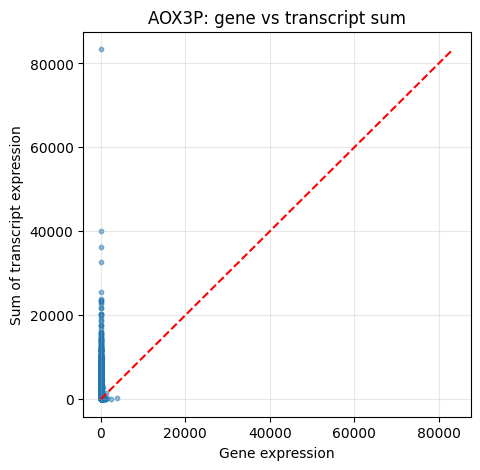

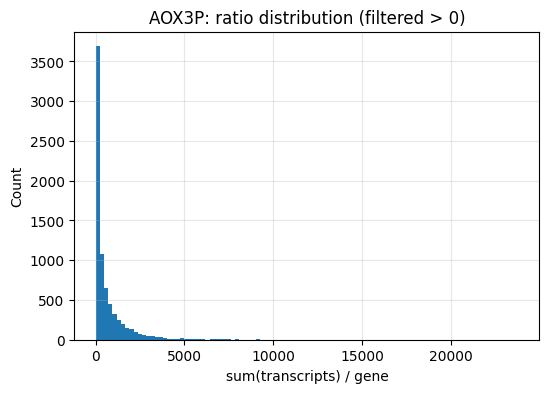


Extreme sample index: 18483
Gene expression: 0
Sum of transcripts: 83379

Top contributing transcripts:
ENST00000491025    83379
ENST00000484406        0
ENST00000469595        0
dtype: uint32


In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def to_numpy(x):
    if hasattr(x, "toarray"):
        x = x.toarray()
    return np.asarray(x)


def get_col_index(var_names, key):
    loc = var_names.get_loc(key)
    if isinstance(loc, slice):
        raise ValueError(f"Expected unique key, got slice for: {key}")
    if isinstance(loc, np.ndarray):
        raise ValueError(f"Expected unique key, got array for: {key}")
    return int(loc)


# -------------------------
# 1. Load gene-to-transcript mapping
# -------------------------
mapping_path = Path("/work3/s252608/DL_project/data/bulk_gene_to_transcripts.json")

with open(mapping_path) as f:
    gene_to_tx = json.load(f)

print(f"Loaded mapping for {len(gene_to_tx)} genes")


# -------------------------
# 2. Validate AnnData alignment
# -------------------------
assert adata_gene.n_obs == adata_tx.n_obs, "Mismatch in number of samples"
assert (adata_gene.obs_names == adata_tx.obs_names).all(), "Sample order mismatch"

print("Gene shape:", adata_gene.shape)
print("Transcript shape:", adata_tx.shape)
print("QC dataframe:", df.shape)


# -------------------------
# 3. Select a problematic gene from QC results
# -------------------------
df_clean = df.replace([np.inf, -np.inf], np.nan)

bad_genes = df_clean[
    (df_clean["corr_gene_vs_sum_iso"] < 0.3) |
    (~df_clean["median_ratio_sumTx_to_gene"].between(0.5, 1.5))
].dropna(subset=["corr_gene_vs_sum_iso"])

if bad_genes.empty:
    raise ValueError("No bad genes found under current criteria")

gene_id = bad_genes.sort_values("corr_gene_vs_sum_iso").iloc[0]["gene_id"]
print(f"Selected gene: {gene_id}")


# -------------------------
# 4. Get transcripts for the gene
# -------------------------
if gene_id not in gene_to_tx:
    raise ValueError(f"{gene_id} not found in mapping")

raw_tx_list = gene_to_tx[gene_id]
tx_list = [t for t in raw_tx_list if t in adata_tx.var_names]

if len(tx_list) == 0:
    raise ValueError(f"No transcripts found for {gene_id} in adata_tx")

print(f"Mapped transcripts in JSON: {len(raw_tx_list)}")
print(f"Transcripts present in adata_tx: {len(tx_list)}")
print("First transcripts:", tx_list[:10])

gene_idx = get_col_index(adata_gene.var_names, gene_id)

tx_pairs = sorted((get_col_index(adata_tx.var_names, t), t) for t in tx_list)
tx_idx = [i for i, _ in tx_pairs]
tx_list = [t for _, t in tx_pairs]

print(f"gene_idx: {gene_idx}")
print(f"Number of tx_idx: {len(tx_idx)}")


# -------------------------
# 5. Extract expression data safely in blocks
# -------------------------
n_obs = adata_gene.n_obs
block_size = 512
eps = 1e-8

g_blocks = []
sum_tx_blocks = []
top_high_blocks = []
top_low_blocks = []

for start in range(0, n_obs, block_size):
    end = min(start + block_size, n_obs)

    g_block = to_numpy(adata_gene[start:end, gene_idx].X).reshape(-1)

    tx_cols = []
    for j in tx_idx:
        col = to_numpy(adata_tx[start:end, j].X).reshape(-1)
        tx_cols.append(col)

    tx_block = np.column_stack(tx_cols)

    sum_block = tx_block.sum(axis=1)
    ratio_block = sum_block / (g_block + eps)
    abs_error_block = np.abs(g_block.astype(np.float64) - sum_block.astype(np.float64))

    block_df = pd.DataFrame({
        "sample_idx": np.arange(start, end),
        "gene_expr": g_block,
        "sum_iso_expr": sum_block,
        "ratio": ratio_block,
        "abs_error": abs_error_block,
    })

    top_high_blocks.append(block_df.nlargest(5, "ratio"))
    top_low_blocks.append(block_df.nsmallest(5, "ratio"))

    g_blocks.append(g_block)
    sum_tx_blocks.append(sum_block)

g_expr = np.concatenate(g_blocks)
sum_tx = np.concatenate(sum_tx_blocks)

df_example = pd.DataFrame({
    "sample_idx": np.arange(n_obs),
    "gene_expr": g_expr,
    "sum_iso_expr": sum_tx,
    "ratio": sum_tx / (g_expr + eps),
    "abs_error": np.abs(g_expr - sum_tx),
})

print("\nPreview:")
print(df_example.head())


# -------------------------
# 6. Inspect extreme cases
# -------------------------
top_high = pd.concat(top_high_blocks).nlargest(10, "ratio")
top_low = pd.concat(top_low_blocks).nsmallest(10, "ratio")

print("\nTop cases: isoforms >> gene")
print(top_high)

print("\nTop cases: gene >> isoforms")
print(top_low)


# -------------------------
# 7. Scatter plot
# -------------------------
plt.figure(figsize=(5, 5))
plt.scatter(g_expr, sum_tx, alpha=0.5, s=10)

max_val = max(float(g_expr.max()), float(sum_tx.max()))
plt.plot([0, max_val], [0, max_val], "r--")

plt.xlabel("Gene expression")
plt.ylabel("Sum of transcript expression")
plt.title(f"{gene_id}: gene vs transcript sum")
plt.grid(alpha=0.3)
plt.show()


# -------------------------
# 8. Ratio distribution
# -------------------------
valid_ratio = (g_expr > 0) & (sum_tx > 0)
ratio = sum_tx[valid_ratio] / (g_expr[valid_ratio] + eps)
ratio = ratio[np.isfinite(ratio)]

plt.figure(figsize=(6, 4))
plt.hist(ratio, bins=100)
plt.xlabel("sum(transcripts) / gene")
plt.ylabel("Count")
plt.title(f"{gene_id}: ratio distribution (filtered > 0)")
plt.grid(alpha=0.3)
plt.show()


# -------------------------
# 9. Inspect transcript contributions in worst sample
# -------------------------
idx = int(df_example["ratio"].idxmax())
sample_idx = int(df_example.loc[idx, "sample_idx"])

tx_one = []
for j in tx_idx:
    value = to_numpy(adata_tx[sample_idx:sample_idx + 1, j].X).reshape(-1)[0]
    tx_one.append(value)

iso_series = pd.Series(tx_one, index=tx_list).sort_values(ascending=False)

print(f"\nExtreme sample index: {sample_idx}")
print(f"Gene expression: {g_expr[sample_idx]}")
print(f"Sum of transcripts: {sum_tx[sample_idx]}")

print("\nTop contributing transcripts:")
print(iso_series.head(10))